# Machine Learning-Based Visible Light Positioning

## Predicting Receiver Position from Optical Signal Measurements

This project investigates the use of machine learning to estimate the two-dimensional position of a receiver in a Visible Light Positioning (VLP) environment.

The models use optical signal measurements from multiple luminaires as input features and predict the receiver's $(x,y)$ coordinates.

## 1. Introduction

Visible Light Positioning (VLP) uses visible light signals from luminaires to estimate the position of a receiver.

In this project, machine learning is used to learn the relationship between optical signal measurements and the physical position of the receiver.

The machine learning problem is formulated as:

**Input:** Optical signal measurements from 11 luminaires (L1–L11)

**Output:** Receiver position $(x,y)$

Three regression approaches are evaluated:

1. Random Forest
2. K-Nearest Neighbors (KNN)
3. Multi-Layer Perceptron (MLP) Neural Network

The models are evaluated using Euclidean positioning error in metres.

In [12]:
import matplotlib.pyplot as plt

## 2. Dataset

The project uses the Public VLP Dataset.

The dataset contains measurements from 11 luminaires together with the corresponding two-dimensional receiver coordinates.

The main variables are:

- `L1`–`L11`: optical signal measurements
- `x`: receiver x-coordinate
- `y`: receiver y-coordinate
- `level_0`, `index`: dataset identifiers

In [5]:
import pandas as pd
from google.colab import files

df = pd.read_csv("Public_VLP_Dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7344, 14)


,index,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10,L11,x,y
0,0,15.0,23.893122,39.405362,191.227092,68.628566,15.0,86.628103,282.928669,64.751934,35.857665,15.0,3.684493,1.733080
1,1,15.0,25.834706,40.269304,215.163688,53.172126,15.0,65.938937,314.402304,67.591192,35.151599,15.0,3.682122,1.518624
2,2,15.0,19.699516,43.623517,234.470798,43.794282,15.0,53.995155,331.835963,69.891430,28.650815,15.0,3.680984,1.276831
3,3,15.0,19.363725,43.220782,222.716910,39.423066,15.0,41.133686,336.608655,71.597389,28.532250,15.0,3.680257,1.034484
4,4,15.0,17.633501,40.052924,208.304308,28.006412,15.0,33.895850,314.559317,69.771484,24.902615,15.0,3.679607,0.703489


## 3. Data Preparation

The identifier columns are excluded from the machine learning inputs.

The 11 optical measurements (`L1`–`L11`) are used as input features, while `x` and `y` are the prediction targets.

Therefore:

**X:** 7,344 samples × 11 optical features

**y:** 7,344 samples × 2 position coordinates

In [7]:
X = df[[f"L{i}" for i in range(1, 12)]]
y = df[["x", "y"]]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7344, 11)
y shape: (7344, 2)


## 4. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to train the models, while the testing data is reserved for evaluating their predictions on unseen samples.

In [6]:
X = df[[f"L{i}" for i in range(1, 12)]]
y = df[["x", "y"]]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5875
Testing samples: 1469


## 5. Random Forest Model

A Random Forest Regressor is first used as the main baseline model.

The model combines multiple decision trees to learn the relationship between the optical measurements and receiver position.

The prediction error is calculated as the Euclidean distance between the predicted and actual receiver coordinates:

$$
e = \sqrt{(x_{pred}-x_{actual})^2 + (y_{pred}-y_{actual})^2}
$$

In [13]:
import numpy as np
y_test_array = y_test.to_numpy()

x_error = y_pred[:, 0] - y_test_array[:, 0]
y_error = y_pred[:, 1] - y_test_array[:, 1]

position_error = np.sqrt(x_error**2 + y_error**2)

mean_position_error = np.mean(position_error)

print(f"Mean positioning error: {mean_position_error:.4f} m")

Mean positioning error: 0.0983 m


## 6. K-Nearest Neighbors

KNN estimates the receiver position by finding training samples with similar optical signal measurements.

Five nearest neighbours are used for each prediction.

In [14]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_error = np.sqrt(
    (knn_pred[:, 0] - y_test_array[:, 0])**2 +
    (knn_pred[:, 1] - y_test_array[:, 1])**2
)

knn_mean_error = np.mean(knn_error)

print(f"KNN mean positioning error: {knn_mean_error:.4f} m")

KNN mean positioning error: 0.1169 m


## 7. Neural Network Model

A Multi-Layer Perceptron (MLP) neural network is evaluated as a nonlinear regression model.

The network contains two hidden layers with 64 and 32 neurons.

The input features are standardized before training because neural networks generally benefit from features being placed on comparable numerical scales.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)

mlp_error = np.sqrt(
    (mlp_pred[:, 0] - y_test_array[:, 0])**2 +
    (mlp_pred[:, 1] - y_test_array[:, 1])**2
)

mlp_mean_error = np.mean(mlp_error)

print(f"MLP mean positioning error: {mlp_mean_error:.4f} m")

MLP mean positioning error: 0.1168 m


## 8. Model Comparison

The three models are compared using mean Euclidean positioning error.

Lower error indicates better positioning accuracy.

In [17]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "KNN",
        "MLP Neural Network"
    ],
    "Mean Positioning Error (m)": [
        mean_position_error,
        knn_mean_error,
        mlp_mean_error
    ]
})

results.sort_values("Mean Positioning Error (m)")

,Model,Mean Positioning Error (m)
0,Random Forest,0.098303
2,MLP Neural Network,0.116819
1,KNN,0.116927


## 9. Error Analysis

The Random Forest predictions are compared with the actual receiver positions.

The error distribution is also examined to determine how consistently the model performs and to identify potential outliers.

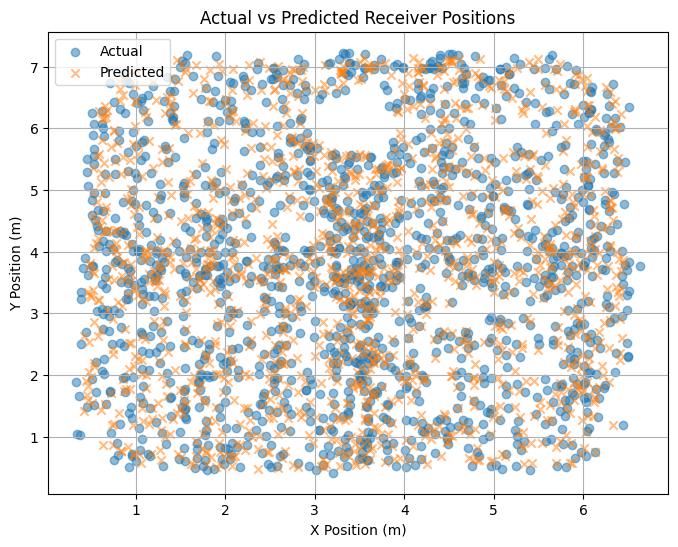

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_array[:, 0],
    y_test_array[:, 1],
    label="Actual",
    alpha=0.5
)

plt.scatter(
    y_pred[:, 0],
    y_pred[:, 1],
    label="Predicted",
    alpha=0.5,
    marker="x"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Actual vs Predicted Receiver Positions")
plt.legend()
plt.grid(True)

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


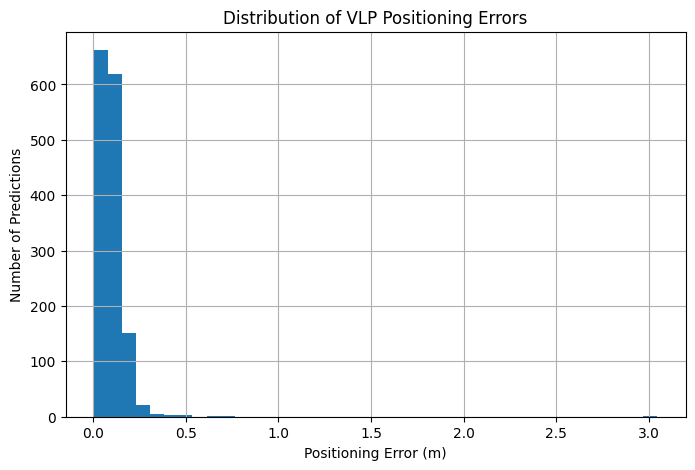

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(position_error, bins=40)

plt.xlabel("Positioning Error (m)")
plt.ylabel("Number of Predictions")
plt.title("Distribution of VLP Positioning Errors")

plt.grid(True)

plt.savefig("error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print(f"Minimum error: {np.min(position_error):.4f} m")
print(f"Maximum error: {np.max(position_error):.4f} m")
print(f"Median error: {np.median(position_error):.4f} m")
print(f"95th percentile error: {np.percentile(position_error, 95):.4f} m")

Minimum error: 0.0041 m
Maximum error: 3.0456 m
Median error: 0.0858 m
95th percentile error: 0.1972 m


## 10. Feature Importance

The Random Forest feature importance is examined to determine which luminaires contribute most strongly to position prediction.

L4, L1 and L9 were the three most influential features in the trained model.

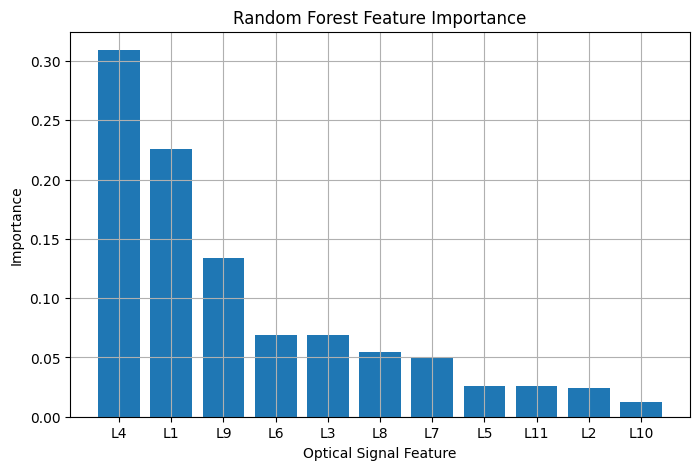

In [26]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Optical Signal Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.grid(True)

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## 11. Conclusion

This project investigated machine learning-based Visible Light Positioning using optical signal measurements from 11 luminaires.

Three regression models were evaluated: Random Forest, KNN and an MLP neural network.

The Random Forest achieved the lowest mean positioning error of approximately **9.83 cm** on the test set.

The results demonstrate that machine learning can learn the relationship between multi-luminaires optical measurements and receiver position without explicitly implementing a traditional geometric positioning algorithm.

The feature-importance analysis also showed that the contribution of individual luminaires is not uniform, with L4, L1 and L9 providing the strongest contributions to the Random Forest predictions.

### Limitations

The evaluation used a random train-test split. Because the dataset contains spatially clustered measurements, this may provide an optimistic estimate of spatial generalization.

### Future Work

Future work could investigate:

- spatially separated train-test evaluation
- robustness to measurement noise
- additional machine learning models
- real-time implementation on embedded hardware
- integration with a physical VLC sensing system

In [21]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "KNN",
        "MLP Neural Network"
    ],
    "Mean Positioning Error (m)": [
        mean_position_error,
        knn_mean_error,
        mlp_mean_error
    ]
})

results = results.sort_values("Mean Positioning Error (m)")

results

,Model,Mean Positioning Error (m)
0,Random Forest,0.098303
2,MLP Neural Network,0.116819
1,KNN,0.116927


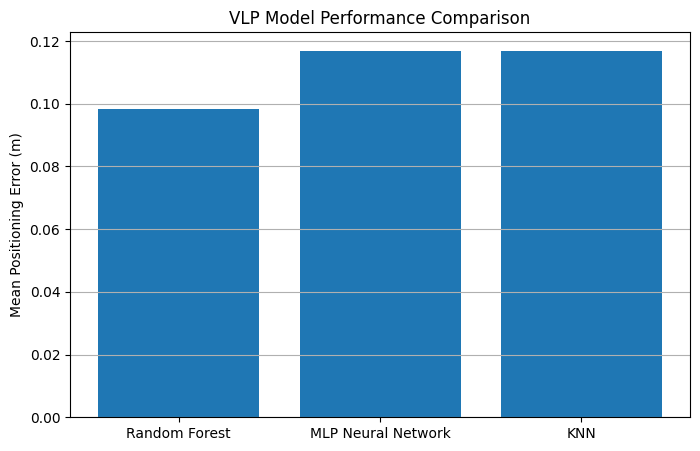

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Mean Positioning Error (m)"]
)

plt.ylabel("Mean Positioning Error (m)")
plt.title("VLP Model Performance Comparison")
plt.grid(axis="y")

plt.show()